# Prepared by: Safal Sapkota
# AI Coursework: Lab 3 (Neural Network)
# Date: March 1, 2026



---

1. **Introduction**

An Artificial Neural Network (ANN) is a computational model made of interconnected neurons arranged in layers:

Input Layer

Hidden Layer(s)

Output Layer

Each neuron performs a weighted sum followed by an activation:

$$z=wTx+b$$

The activation function introduces non-linearity:

$$a=f(z)$$

---

2. **Linear vs Non-Linear Classification**

A linear classifier separates data using a straight line (or hyperplane):

$$w1x1+w2x2+b=0$$

However, circular datasets are non-linearly separable. Their boundary resembles:

$$x2+y2=r2$$

Thus, non-linear activation functions and deeper architectures are required.
 
 ---

3. **Activation Functions**

Activation functions allow networks to learn complex patterns.

**Sigmoid**
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Output range: (0,1)

Used for binary classification

**ReLU**

$$f(x)=max(0,x)$$

Efficient and widely used

Reduces vanishing gradient issues

---

4. **Loss Function**

For binary classification, Binary Cross Entropy is used:

$$
L = - \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
$$

It measures the difference between true labels and predicted probabilities.

---

5. **Training Process**

Training a neural network involves the following steps:

1. **Forward Propagation**  
   Compute predictions using current weights.

2. **Loss Computation**  
   Measure error between predicted and true values.

3. **Backpropagation**  
   Compute gradients of the loss with respect to weights.

4. **Weight Update (Gradient Descent)**  

$$
w = w - \eta \frac{\partial L}{\partial w}
$$
where
- $\eta$ = learning rate  
- $\frac{\partial L}{\partial w}$ = gradient of the loss with respect to weights 

---

6. **Effect of Network Architecture**

Linear model → fails on circular data

Single hidden layer → moderate performance

Deeper network → better representation of circular boundary

Increasing depth improves learning capacity but may increase overfitting risk.

---

In [1]:
import pandas as pd 

#  1. Data retreival and check 

In [2]:
df = pd.read_csv("circles_binary_classification.csv")

In [3]:
df.sample(20)


,X1,X2,label
967,0.873172,-0.542520,0
167,-0.561175,0.580646,1
321,-0.243097,0.956267,0
179,-0.470204,0.636631,1
101,-0.234602,-0.964001,0
32,0.008444,0.783602,1
740,-0.702784,-0.314717,1
460,0.622759,0.773766,0
200,0.949494,0.355544,0
920,-0.846829,0.541398,0


In [4]:
df.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [5]:
df.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   label   1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


# 2. Data cleaning & feature design

In [7]:
# Missing Value 

In [8]:
print(df.isnull().sum())

X1       0
X2       0
label    0
dtype: int64


In [9]:
# Create features X and target y
X = df[['X1', 'X2']].values 
y = df['label'].values  

In [10]:
X 

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [11]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [12]:
import torch
import numpy as np

In [13]:
# Here I use Pytorch 

In [14]:
# Convert to PyTorch tensors with float32 dtype
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32).unsqueeze(1)

# 3 . Visulization

In [15]:
import matplotlib.pyplot as plt 

Text(0.5, 1.0, 'Scatter Plot of Circles Dataset')

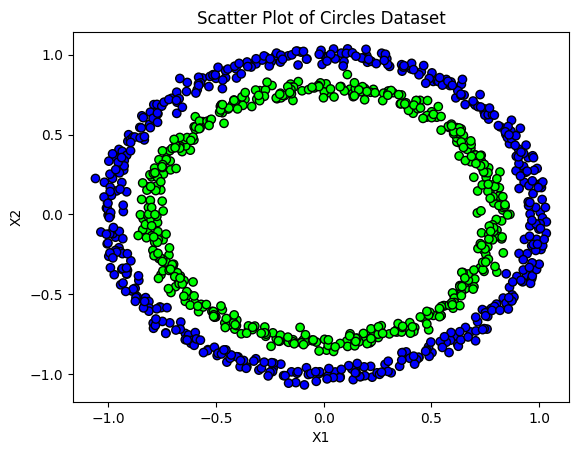

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='brg', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter Plot of Circles Dataset')

# 4. Train Test split 

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Device & dtype

In [19]:
# Set device to CUDA if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
# Move tensors to device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# 6. Implementation of Baseline Model 

In [21]:
import torch.nn as nn

# Set manual seed for reproducibility
torch.manual_seed(42)

# Define ModelV0: Linear model with 2 -> 5 -> 1, no activation
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 5)
        self.layer2 = nn.Linear(5, 1)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return x

In [22]:
# Define ModelV1: Linear model with 2 -> 15 -> 15 -> 1, no activation
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 15)
        self.layer2 = nn.Linear(15, 15)
        self.layer3 = nn.Linear(15, 1)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x

In [23]:
 # Define ModelV2: Non-linear model with 2 -> 64 -> 64 -> 10 -> 1, ReLU activations
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 10)
        self.layer4 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.layer4(x)
        return x

# 7. Loss Optimizer & Matrix 

In [24]:
# Function to calculate accuracy
def accuracy_fn(y_true, y_pred_logits):
    y_pred = torch.round(torch.sigmoid(y_pred_logits))  # Apply sigmoid and round
    return (y_pred == y_true).sum() / len(y_true) * 100  # Percentage accuracy

# Training and testing loop function
def train_and_test_loop(model, epochs, optimizer, loss_fn, X_train, y_train, X_test, y_test):
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        # Training mode
        model.train()
        y_logits = model(X_train)
        loss = loss_fn(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_acc = accuracy_fn(y_train, y_logits)
        train_accs.append(train_acc.item())
        
        # Evaluation mode
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)
            test_acc = accuracy_fn(y_test, test_logits)
        
        test_losses.append(test_loss.item())
        test_accs.append(test_acc.item())
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch: {epoch+1} | Train loss: {loss.item():.4f} | Train acc: {train_acc:.2f}% | Test loss: {test_loss.item():.4f} | Test acc: {test_acc:.2f}%")
    
    return train_losses, test_losses, train_accs, test_accs

# Loss function
loss_fn = nn.BCEWithLogitsLoss()

# 8 . Training loop

In [25]:
# Train V0 Model 
# Initialize ModelV0 and optimizer
model_v0 = ModelV0().to(device)
optimizer_v0 = torch.optim.SGD(model_v0.parameters(), lr=0.1)

# Train for 100 epochs
train_losses_v0, test_losses_v0, train_accs_v0, test_accs_v0 = train_and_test_loop(
    model_v0, 100, optimizer_v0, loss_fn, X_train, y_train, X_test, y_test
)

Epoch: 10 | Train loss: 0.6941 | Train acc: 50.00% | Test loss: 0.6962 | Test acc: 50.00%
Epoch: 20 | Train loss: 0.6935 | Train acc: 46.00% | Test loss: 0.6959 | Test acc: 47.00%
Epoch: 30 | Train loss: 0.6932 | Train acc: 49.25% | Test loss: 0.6958 | Test acc: 47.00%
Epoch: 40 | Train loss: 0.6931 | Train acc: 49.12% | Test loss: 0.6957 | Test acc: 46.50%
Epoch: 50 | Train loss: 0.6931 | Train acc: 50.13% | Test loss: 0.6957 | Test acc: 46.50%
Epoch: 60 | Train loss: 0.6931 | Train acc: 50.25% | Test loss: 0.6956 | Test acc: 46.50%
Epoch: 70 | Train loss: 0.6930 | Train acc: 50.25% | Test loss: 0.6956 | Test acc: 46.50%
Epoch: 80 | Train loss: 0.6930 | Train acc: 50.75% | Test loss: 0.6955 | Test acc: 46.50%
Epoch: 90 | Train loss: 0.6930 | Train acc: 50.38% | Test loss: 0.6955 | Test acc: 46.50%
Epoch: 100 | Train loss: 0.6930 | Train acc: 50.50% | Test loss: 0.6954 | Test acc: 46.50%


In [26]:
# Train V1 Model 
# Reinitialize ModelV1 and optimizer
model_v1 = ModelV1().to(device)
optimizer_v1 = torch.optim.SGD(model_v1.parameters(), lr=0.1)

# Train for 1000 epochs
train_losses_v1, test_losses_v1, train_accs_v1, test_accs_v1 = train_and_test_loop(
    model_v1, 1000, optimizer_v1, loss_fn, X_train, y_train, X_test, y_test
)

Epoch: 10 | Train loss: 0.6938 | Train acc: 50.13% | Test loss: 0.6934 | Test acc: 52.50%
Epoch: 20 | Train loss: 0.6935 | Train acc: 49.75% | Test loss: 0.6934 | Test acc: 52.50%
Epoch: 30 | Train loss: 0.6934 | Train acc: 49.62% | Test loss: 0.6935 | Test acc: 53.50%
Epoch: 40 | Train loss: 0.6933 | Train acc: 49.12% | Test loss: 0.6936 | Test acc: 52.00%
Epoch: 50 | Train loss: 0.6932 | Train acc: 49.12% | Test loss: 0.6937 | Test acc: 51.00%
Epoch: 60 | Train loss: 0.6931 | Train acc: 50.50% | Test loss: 0.6938 | Test acc: 51.50%
Epoch: 70 | Train loss: 0.6931 | Train acc: 50.50% | Test loss: 0.6939 | Test acc: 49.50%
Epoch: 80 | Train loss: 0.6931 | Train acc: 50.75% | Test loss: 0.6940 | Test acc: 47.50%
Epoch: 90 | Train loss: 0.6930 | Train acc: 50.25% | Test loss: 0.6941 | Test acc: 47.50%
Epoch: 100 | Train loss: 0.6930 | Train acc: 51.12% | Test loss: 0.6941 | Test acc: 46.50%
Epoch: 110 | Train loss: 0.6930 | Train acc: 50.75% | Test loss: 0.6942 | Test acc: 46.00%
Epoch: 1

In [27]:
# Train V2 Model 
# Reinitialize ModelV2 and optimizer
model_v2 = ModelV2().to(device)
optimizer_v2 = torch.optim.SGD(model_v2.parameters(), lr=0.1)

# Train for 1500 epochs
train_losses_v2, test_losses_v2, train_accs_v2, test_accs_v2 = train_and_test_loop(
    model_v2, 1500, optimizer_v2, loss_fn, X_train, y_train, X_test, y_test
)

Epoch: 10 | Train loss: 0.6930 | Train acc: 50.00% | Test loss: 0.6927 | Test acc: 50.00%
Epoch: 20 | Train loss: 0.6917 | Train acc: 53.62% | Test loss: 0.6917 | Test acc: 52.50%
Epoch: 30 | Train loss: 0.6909 | Train acc: 62.37% | Test loss: 0.6910 | Test acc: 61.50%
Epoch: 40 | Train loss: 0.6902 | Train acc: 54.25% | Test loss: 0.6905 | Test acc: 58.50%
Epoch: 50 | Train loss: 0.6897 | Train acc: 53.62% | Test loss: 0.6901 | Test acc: 56.00%
Epoch: 60 | Train loss: 0.6891 | Train acc: 53.25% | Test loss: 0.6898 | Test acc: 53.50%
Epoch: 70 | Train loss: 0.6886 | Train acc: 53.62% | Test loss: 0.6894 | Test acc: 55.00%
Epoch: 80 | Train loss: 0.6879 | Train acc: 54.00% | Test loss: 0.6889 | Test acc: 55.50%
Epoch: 90 | Train loss: 0.6873 | Train acc: 54.00% | Test loss: 0.6883 | Test acc: 56.50%
Epoch: 100 | Train loss: 0.6865 | Train acc: 54.62% | Test loss: 0.6876 | Test acc: 56.50%
Epoch: 110 | Train loss: 0.6858 | Train acc: 55.37% | Test loss: 0.6871 | Test acc: 57.00%
Epoch: 1

In [28]:
# 9 . Predictions & evaluation
import numpy as np

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    model.eval()
    # Create meshgrid for plotting
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    spacing = min(x_max - x_min, y_max - y_min) / 100
    XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing), np.arange(y_min, y_max, spacing))
    
    # Predict on meshgrid points
    data = torch.from_numpy(np.column_stack((XX.ravel(), YY.ravel()))).float().to(device)
    with torch.inference_mode():
        z = torch.sigmoid(model(data))
    z = z.cpu().numpy().reshape(XX.shape)
    
    # Plot contour and data points
    plt.contourf(XX, YY, z, cmap='viridis', alpha=0.8)
    plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.squeeze().cpu(), cmap='viridis', edgecolor='k')
    plt.title(title)
    plt.show()

C:\Users\anush\AppData\Local\Temp\ipykernel_8152\1704070788.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing), np.arange(y_min, y_max, spacing))


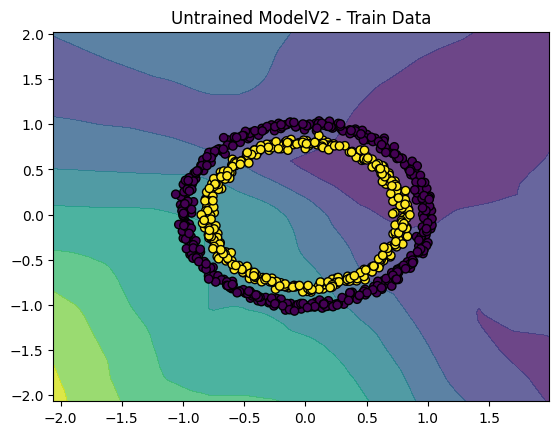

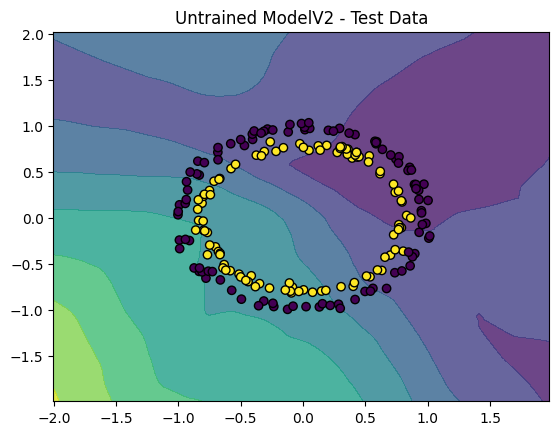

In [29]:
# Initialize an untrained model for comparison
untrained_model = ModelV2().to(device)  # Using V2 as example

# Plot decision boundary for untrained model on train data
plot_decision_boundary(untrained_model, X_train, y_train, 'Untrained ModelV2 - Train Data')

# Plot for test data
plot_decision_boundary(untrained_model, X_test, y_test, 'Untrained ModelV2 - Test Data')

C:\Users\anush\AppData\Local\Temp\ipykernel_8152\1704070788.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing), np.arange(y_min, y_max, spacing))


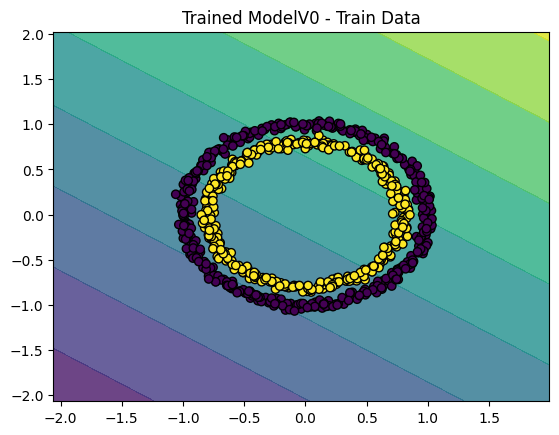

In [30]:
# Plot decision boundary for trained ModelV0 on train data
plot_decision_boundary(model_v0, X_train, y_train, 'Trained ModelV0 - Train Data')

C:\Users\anush\AppData\Local\Temp\ipykernel_8152\1704070788.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing), np.arange(y_min, y_max, spacing))


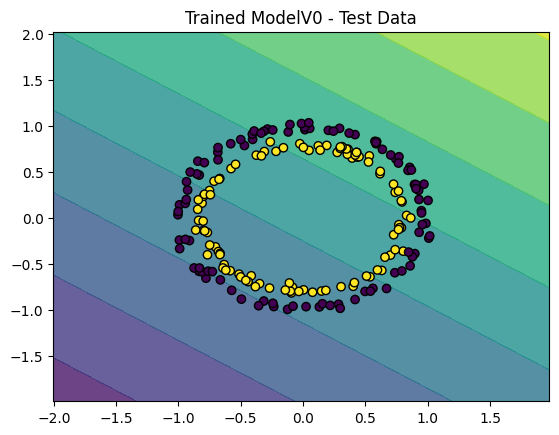

In [31]:
# Plot for test data
plot_decision_boundary(model_v0, X_test, y_test, 'Trained ModelV0 - Test Data')

C:\Users\anush\AppData\Local\Temp\ipykernel_8152\1704070788.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing), np.arange(y_min, y_max, spacing))


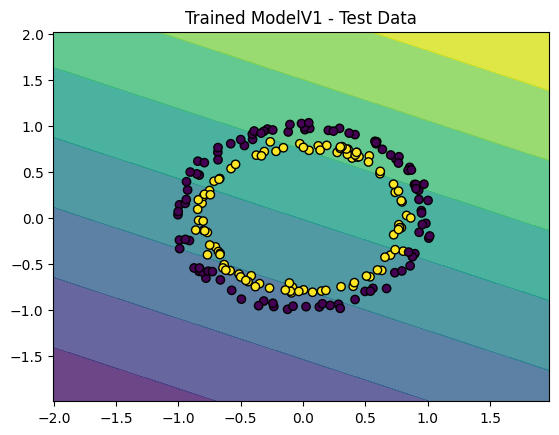

In [32]:
plot_decision_boundary(model_v1, X_test, y_test, 'Trained ModelV1 - Test Data')

C:\Users\anush\AppData\Local\Temp\ipykernel_8152\1704070788.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing), np.arange(y_min, y_max, spacing))


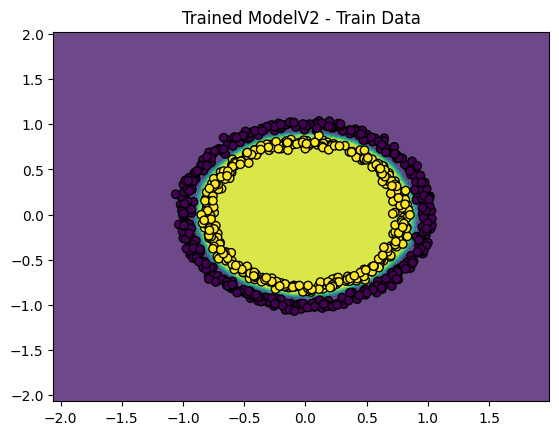

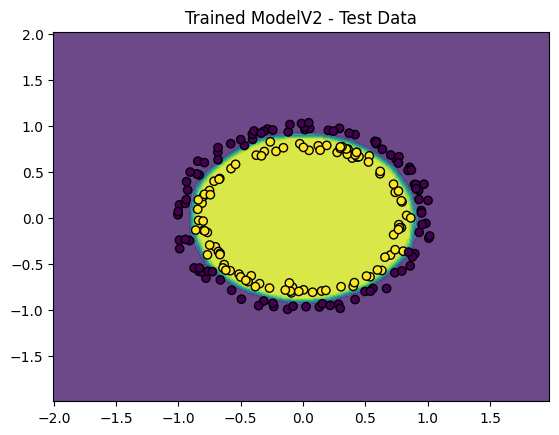

In [33]:
#Repeat for ModelV2
plot_decision_boundary(model_v2, X_train, y_train, 'Trained ModelV2 - Train Data')
plot_decision_boundary(model_v2, X_test, y_test, 'Trained ModelV2 - Test Data')

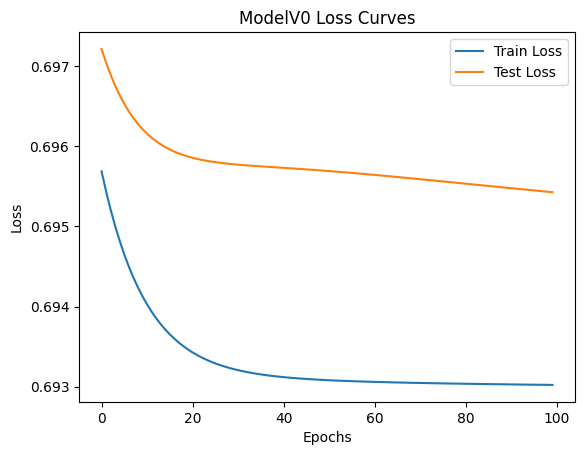

In [34]:
# 10 . Discussion and Evaluation 
# Function to plot loss curves
def plot_loss_curves(train_losses, test_losses, title):
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()

# Plot for ModelV0
plot_loss_curves(train_losses_v0, test_losses_v0, 'ModelV0 Loss Curves')

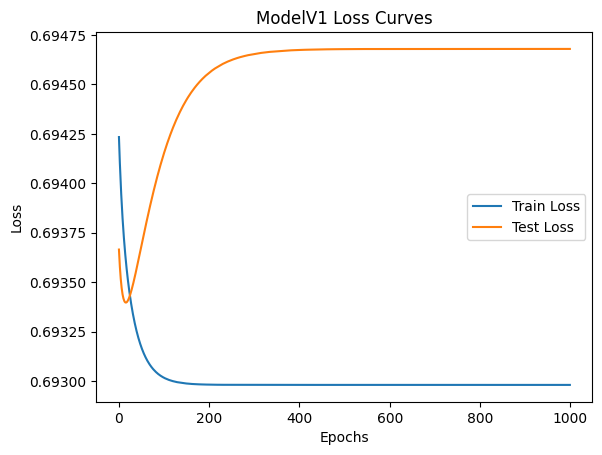

In [35]:
# Plot for ModelV1
plot_loss_curves(train_losses_v1, test_losses_v1, 'ModelV1 Loss Curves')

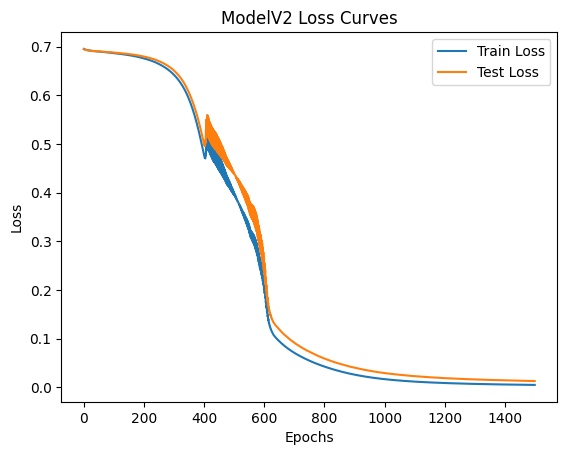

In [36]:
# Plot for ModelV2
plot_loss_curves(train_losses_v2, test_losses_v2, 'ModelV2 Loss Curves')

# Optimizer SGD and  ADam (GD)

Epoch: 10 | Train loss: 0.6961 | Train acc: 50.00% | Test loss: 0.6956 | Test acc: 50.00%
Epoch: 20 | Train loss: 0.6895 | Train acc: 51.88% | Test loss: 0.6907 | Test acc: 50.00%
Epoch: 30 | Train loss: 0.6801 | Train acc: 66.25% | Test loss: 0.6837 | Test acc: 65.00%
Epoch: 40 | Train loss: 0.6642 | Train acc: 77.12% | Test loss: 0.6695 | Test acc: 77.50%
Epoch: 50 | Train loss: 0.6381 | Train acc: 91.38% | Test loss: 0.6450 | Test acc: 88.50%
Epoch: 60 | Train loss: 0.5947 | Train acc: 99.12% | Test loss: 0.6031 | Test acc: 98.50%
Epoch: 70 | Train loss: 0.5328 | Train acc: 99.38% | Test loss: 0.5455 | Test acc: 98.50%
Epoch: 80 | Train loss: 0.4535 | Train acc: 99.50% | Test loss: 0.4718 | Test acc: 98.50%
Epoch: 90 | Train loss: 0.3640 | Train acc: 99.75% | Test loss: 0.3875 | Test acc: 98.50%
Epoch: 100 | Train loss: 0.2733 | Train acc: 99.88% | Test loss: 0.3009 | Test acc: 99.50%
Epoch: 110 | Train loss: 0.1936 | Train acc: 100.00% | Test loss: 0.2236 | Test acc: 100.00%
Epoch:

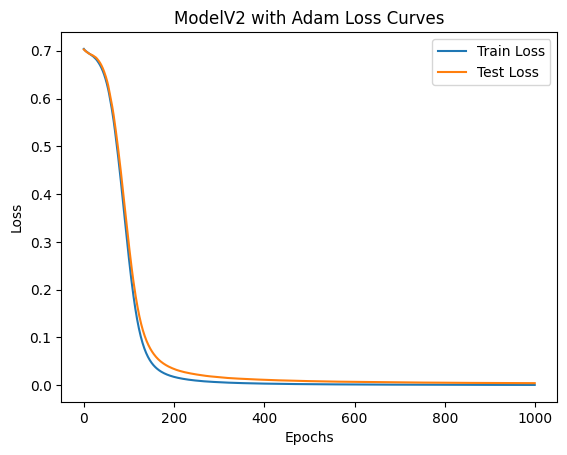

SGD Final Test Acc: 100.00%


In [37]:
# Reinitialize ModelV2 with Adam optimizer
model_v2_adam = ModelV2().to(device)
optimizer_adam = torch.optim.Adam(model_v2_adam.parameters(), lr=0.001)  # Lower lr for Adam

# Train with Adam for 1000 epochs
train_losses_adam, test_losses_adam, train_accs_adam, test_accs_adam = train_and_test_loop(
    model_v2_adam, 1000, optimizer_adam, loss_fn, X_train, y_train, X_test, y_test
)

# Plot loss curves for Adam
plot_loss_curves(train_losses_adam, test_losses_adam, 'ModelV2 with Adam Loss Curves')

# Compare final test accuracy
print(f"SGD Final Test Acc: {test_accs_v2[-1]:.2f}%")

In [38]:
print(f"Adam Final Test Acc: {test_accs_adam[-1]:.2f}%")

Adam Final Test Acc: 100.00%


# Discussion and Conclusion
Being purely linear and lack activation functions, models V0 and V1 are unable to model the non-linear structure of the circles dataset, leading to performance close to random chance (around 50% accuracy). In contrast, Model V2 incorporates ReLU activations, enabling it to learn complex non-linear decision boundaries and achieve significantly higher accuracy (typically exceeding 95%), as illustrated by the decision boundary visualizations. The loss curves further support this observation: Model V2 shows clear convergence during training, whereas the linear models exhibit minimal improvement over time..
